<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/MSc_Project_N1217583.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# For TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# For Grad-CAM
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K
import matplotlib.cm as cm

# For Image Utilities
from PIL import Image
import glob

# Connecting Drive
from google.colab import drive
drive.mount('/content/drive')
from collections import defaultdict

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
plantvillage_path = '/content/drive/MyDrive/Final Project Dataset/PlantVillage'

# Creating a dictionary to hold all image paths by class
dataset = defaultdict(list)

for class_name in os.listdir(plantvillage_path):
    class_path = os.path.join(plantvillage_path, class_name)
    if os.path.isdir(class_path):
        for image_file in os.listdir(class_path):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                dataset[class_name].append(os.path.join(class_path, image_file))

# Print summary
for class_name, images in dataset.items():
    print(f"{class_name}: {len(images)} images")

Tomato__Tomato_mosaic_virus: 373 images
Tomato_Septoria_leaf_spot: 1771 images
Tomato_Bacterial_spot: 2127 images
Tomato_healthy: 1591 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
Tomato_Late_blight: 1909 images
Tomato_Leaf_Mold: 952 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1976 images
Tomato__Target_Spot: 1404 images
Tomato_Early_blight: 1000 images
Potato___healthy: 152 images
Potato___Late_blight: 1000 images
Pepper__bell___healthy: 1478 images
Pepper__bell___Bacterial_spot: 993 images
Potato___Early_blight: 1000 images


In [4]:
# List all files in the folder
# files = os.listdir('/content/drive/MyDrive/Final Project Dataset/PlantVillage/Tomato__Tomato_mosaic_virus')
# print(f"Found {len(files)} files in {'/content/drive/MyDrive/Final Project Dataset/PlantVillage/Tomato__Tomato_mosaic_virus'}")

Found 373 files in /content/drive/MyDrive/Final Project Dataset/PlantVillage/Tomato__Tomato_mosaic_virus


In [17]:
# Creating a dictionary to hold all image paths by class
dataset = defaultdict(list)

for class_name in os.listdir(plantvillage_path):
    class_path = os.path.join(plantvillage_path, class_name)
    if os.path.isdir(class_path):
        for image_file in os.listdir(class_path):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                dataset[class_name].append(os.path.join(class_path, image_file))

#import random
#random.shuffle(image_files_in_folder)
#dataset[class_name] = image_files_in_folder[:max_images_per_class]


# Printing summary
#for class_name, images in dataset.items():
    #print(f"{class_name}: {len(images)} images (max {max_images_per_class} used)")

NameError: name 'image_files_in_folder' is not defined

In [19]:
# Creating a dictionary to hold all image paths by class
dataset = defaultdict(list)

max_images_per_class = 300 # Example value, adjust as needed

for class_name in os.listdir(plantvillage_path):
    class_path = os.path.join(plantvillage_path, class_name)
    if os.path.isdir(class_path):
        # Creating a list to hold image files for the current class
        current_class_image_files = []
        for image_file in os.listdir(class_path):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                current_class_image_files.append(os.path.join(class_path, image_file))

        import random
        # Shuffle the list of image files for the current class
        random.shuffle(current_class_image_files)
        # Assign the shuffled and truncated list to the dataset dictionary
        dataset[class_name] = current_class_image_files[:max_images_per_class]


# summary
for class_name, images in dataset.items():
    # Use max_images_per_class in the print statement for clarity
    print(f"{class_name}: {len(images)} images (max {max_images_per_class} used)")

Tomato__Tomato_mosaic_virus: 300 images (max 300 used)
Tomato_Septoria_leaf_spot: 300 images (max 300 used)
Tomato_Bacterial_spot: 300 images (max 300 used)
Tomato_healthy: 300 images (max 300 used)
Tomato__Tomato_YellowLeaf__Curl_Virus: 300 images (max 300 used)
Tomato_Late_blight: 300 images (max 300 used)
Tomato_Leaf_Mold: 300 images (max 300 used)
Tomato_Spider_mites_Two_spotted_spider_mite: 300 images (max 300 used)
Tomato__Target_Spot: 300 images (max 300 used)
Tomato_Early_blight: 300 images (max 300 used)
Potato___healthy: 152 images (max 300 used)
Potato___Late_blight: 300 images (max 300 used)
Pepper__bell___healthy: 300 images (max 300 used)
Pepper__bell___Bacterial_spot: 300 images (max 300 used)
Potato___Early_blight: 300 images (max 300 used)


#  1. Visualizing Some Sample Images

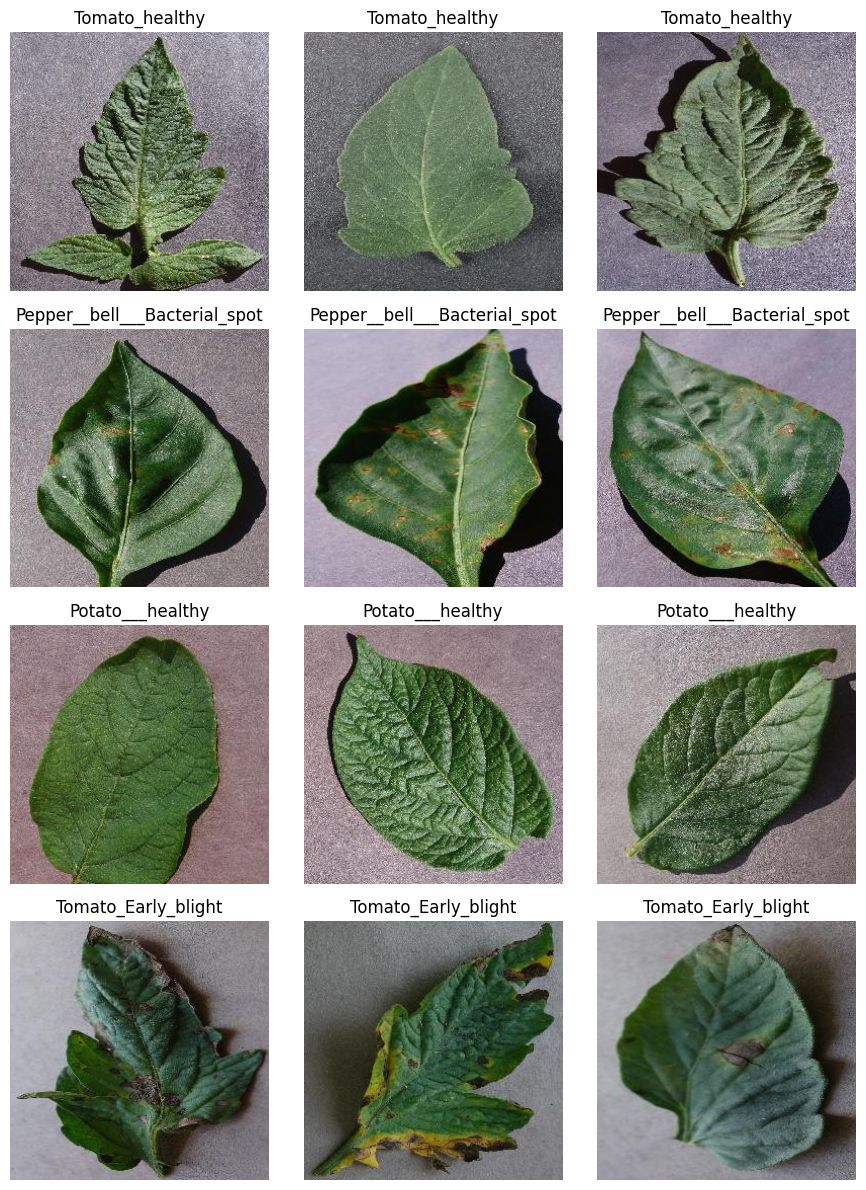

In [20]:
import matplotlib.pyplot as plt
import random

# Display sample images from random classes
def show_sample_images(dataset, num_classes=4, samples_per_class=3):
    class_names = list(dataset.keys())
    random.shuffle(class_names)
    selected_classes = class_names[:num_classes]

    plt.figure(figsize=(samples_per_class * 3, num_classes * 3))

    for i, class_name in enumerate(selected_classes):
        images = dataset[class_name]
        random.shuffle(images)
        for j in range(samples_per_class):
            img = cv2.imread(images[j])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(num_classes, samples_per_class, i * samples_per_class + j + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function
show_sample_images(dataset)

# 2. Preparing Images Paths for Train/Test Split

In [21]:
from sklearn.model_selection import train_test_split

image_paths = []
labels = []

for class_name, files in dataset.items():
    for file in files:
        image_paths.append(file)
        labels.append(class_name)

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

# Split the dataset
X_train, X_val, y_train, y_val = train_test_split(
    image_paths, encoded_labels, test_size=0.2, stratify=encoded_labels, random_state=42
)

print(f"Train samples: {len(X_train)} | Validation samples: {len(X_val)}")


Train samples: 3481 | Validation samples: 871


# 3. Use ImageDataGenerator for Augmentation

In [22]:
# Section 3 itself doesn't produce a visible output in the form of a printed message or a plot.
# However, it performs crucial setup steps that are essential for the following sections of your code,
# particularly for handling and augmenting your image data.

# Here's what Section 3 does:

'''Imports necessary library:
It imports ImageDataGenerator from tensorflow.keras.preprocessing.image. This class is a powerful tool for augmenting image data on the fly.
Defines parameters: It defines two important parameters:

IMG_SIZE:
This sets the target size to which all images will be resized (224x224 pixels in your case). Consistent image size is required for training a CNN.
BATCH_SIZE: This determines the number of images that will be processed together in each batch during training.

Creates ImageDataGenerator instances: It creates two ImageDataGenerator objects:
1. train_datagen: This is configured with various data augmentation techniques such as rotation, shifting, zooming, and horizontal flipping. Data augmentation helps to increase the size and diversity of your training dataset, which can improve the model's generalization ability and reduce overfitting. It also includes rescale=1./255 to normalize pixel values to the range [0, 1], which is a common practice for neural networks.
2. val_datagen: This is configured only with rescale=1./255. Data augmentation is typically applied only to the training data, not the validation or test data, to ensure that the evaluation metrics are based on the original, unaltered images.
Defines a helper function (though not used directly in subsequent sections as written): It defines a function path_to_tensor. While this function is defined, the following sections use a different approach (tf.data.Dataset) for processing images, so this specific function isn't actively used in your current code flow. However, its presence suggests an alternative way you could have approached image loading if you were using the flow_from_directory method of ImageDataGenerator.

In summary, Section 3 sets up the tools (ImageDataGenerator) and parameters for image preprocessing and data augmentation, which are vital steps before feeding the images into your neural network model for training. Although it doesn't produce direct output, it lays the groundwork for the data loading and processing that happen in Section 4.'''

'''from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Create data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Helper function to load data from paths
def path_to_tensor(image_path, label):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
    img = tf.keras.preprocessing.image.img_to_array(img)
    return img, label'''


In [53]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation set
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Train generator
train_generator = train_datagen.flow_from_directory(
    # Use the correct path to your dataset on Google Drive
    '/content/drive/MyDrive/Final Project Dataset/PlantVillage',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    # Use the correct path to your dataset on Google Drive
    '/content/drive/MyDrive/Final Project Dataset/PlantVillage',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Number of classes
num_classes = len(train_generator.class_indices)

Found 16753 images belonging to 15 classes.
Found 4181 images belonging to 15 classes.


# 4. Creating TensorFlow Dataset from Paths

In [49]:
import tensorflow as tf

# Creating a TensorFlow Dataset object from image paths and labels
def process_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

# Wraping in tf.data.Dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

train_ds = train_ds.map(process_image).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(process_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 5. Building CNN Model (EfficientNetB0-based)

In [24]:
'''from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input

# Define model
def build_model(num_classes):
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base

    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

model = build_model(num_classes=len(le.classes_))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()'''

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [54]:
# SECTION 5: Building CNN model (EfficientNetB0-based)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Load EfficientNetB0 without top layer, with pretrained ImageNet weights
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# Freeze first 100 layers to retain useful ImageNet features, fine-tune rest
for layer in base_model.layers[:100]:
    layer.trainable = False
for layer in base_model.layers[100:]:
    layer.trainable = True

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)  # Helps prevent overfitting
x = Dense(128, activation='relu')(x)

# Define num_classes before using it in the Dense layer
# Get the number of classes from the fitted LabelEncoder
# Make sure 'le' is defined in a previous cell
num_classes = len(le.classes_)


predictions = Dense(num_classes, activation='softmax')(x)  # Final layer

# Final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              # Change the loss function to 'sparse_categorical_crossentropy'
              # to match the sparse integer labels.
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Set up EarlyStopping to prevent overfitting and unnecessary training
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
# Note: The original code uses train_generator and val_generator which are not defined.
# Based on previous sections, you are using train_ds and val_ds (tf.data.Dataset).
# Replace train_generator and val_generator with train_ds and val_ds.
'''history = model.fit(
    train_ds, # Use the TensorFlow Dataset
    validation_data=val_ds, # Use the TensorFlow Dataset
    epochs=30,
    callbacks=[early_stop]
)'''

'history = model.fit(\n    train_ds, # Use the TensorFlow Dataset\n    validation_data=val_ds, # Use the TensorFlow Dataset\n    epochs=30,\n    callbacks=[early_stop]\n)'

# 6. Training the Model

In [55]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True, monitor='val_accuracy', mode='max')
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.1363 - loss: 2.6155

109/109 ━━━━━━━━━━━━━━━━━━━━ 98s 421ms/step - accuracy: 0.1367 - loss: 2.6145 - val_accuracy: 0.0689 - val_loss: 2.7351
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.3115 - loss: 2.1319 - val_accuracy: 0.0643 - val_loss: 2.7107
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.4099 - loss: 1.7942

109/109 ━━━━━━━━━━━━━━━━━━━━ 18s 140ms/step - accuracy: 0.4101 - loss: 1.7936 - val_accuracy: 0.0873 - val_loss: 2.7081
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.4927 - loss: 1.5396

109/109 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.4928 - loss: 1.5393 - val_accuracy: 0.2687 - val_loss: 2.1939
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5576 - loss: 1.3677

109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 126ms/step - accuracy: 0.5576 - loss: 1.3676 - val_accuracy: 0.2801 - val_loss: 2.2596
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 159ms/step - accuracy: 0.5791 - loss: 1.2455 - val_accuracy: 0.2687 - val_loss: 2.5670
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.6385 - loss: 1.1122

109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 196ms/step - accuracy: 0.6383 - loss: 1.1124 - val_accuracy: 0.3938 - val_loss: 1.9209
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.6588 - loss: 1.0204

109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 152ms/step - accuracy: 0.6588 - loss: 1.0204 - val_accuracy: 0.4432 - val_loss: 2.1273
Epoch 9/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.6836 - loss: 0.9392 - val_accuracy: 0.3720 - val_loss: 1.8048
Epoch 10/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 18s 132ms/step - accuracy: 0.7125 - loss: 0.8290 - val_accuracy: 0.3318 - val_loss: 2.4910
Epoch 11/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 22s 153ms/step - accuracy: 0.7079 - loss: 0.8663 - val_accuracy: 0.4018 - val_loss: 2.1059
Epoch 12/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 146ms/step - accuracy: 0.7148 - loss: 0.8396 - val_accuracy: 0.3949 - val_loss: 2.5050
Epoch 13/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 18s 129ms/step - accuracy: 0.7426 - loss: 0.7665 - val_accuracy: 0.3364 - val_loss: 2.8185
Epoch 14/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.7789 - loss: 0.6759 - val_accuracy: 0.2572 - val_loss: 3.0313


In [56]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.3682 - loss: 1.8604
Validation Loss: 1.8048
Validation Accuracy: 0.3720


# 7. Plot Accuracy & Loss Curves

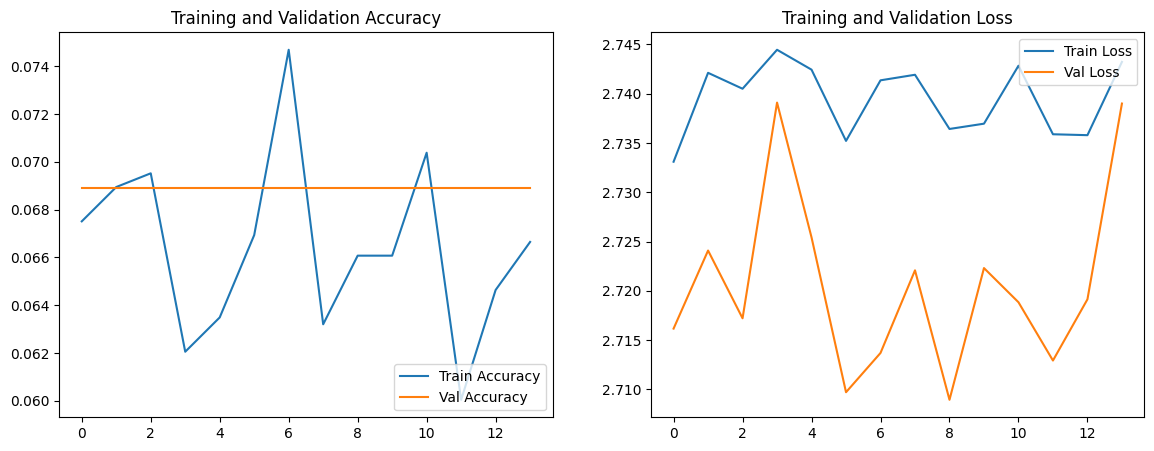

In [26]:
import matplotlib.pyplot as plt

def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_training(history)

# Grad-CAM Visualization

In [11]:
# Loading the Trained Model:
model = load_model('/content/best_model.h5')

# Choosing the PreProcessing Sample Image

In [12]:
# Loading and preprocess an image (update path)

img_path = '/content/drive/MyDrive/IMG_20191216_155825.jpg'
img_size = (224, 224)  # adjusting according to our model's input size

img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Creating a Grad-CAM Heatmap Function

In [13]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Grad-CAM Heatmap function

In [14]:
# Get the base model (EfficientNetB0) from your loaded model
base_model = model.get_layer('efficientnetb0')

# Check the last convolutional layer name inside base_model
for layer in base_model.layers:
    if 'conv' in layer.name:
        print(layer.name)

# Use the correct final convolutional layer name
last_conv_layer_name = 'top_conv'


def make_gradcam_heatmap(img_array, full_model, base_model, last_conv_layer_name, pred_index=None):
    # Get intermediate conv output + full model output
    grad_model = tf.keras.models.Model(
        [full_model.inputs],
        [base_model.get_layer(last_conv_layer_name).output, full_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

stem_conv_pad
stem_conv
block1a_dwconv
block1a_project_conv
block2a_expand_conv
block2a_dwconv_pad
block2a_dwconv
block2a_project_conv
block2b_expand_conv
block2b_dwconv
block2b_project_conv
block3a_expand_conv
block3a_dwconv_pad
block3a_dwconv
block3a_project_conv
block3b_expand_conv
block3b_dwconv
block3b_project_conv
block4a_expand_conv
block4a_dwconv_pad
block4a_dwconv
block4a_project_conv
block4b_expand_conv
block4b_dwconv
block4b_project_conv
block4c_expand_conv
block4c_dwconv
block4c_project_conv
block5a_expand_conv
block5a_dwconv
block5a_project_conv
block5b_expand_conv
block5b_dwconv
block5b_project_conv
block5c_expand_conv
block5c_dwconv
block5c_project_conv
block6a_expand_conv
block6a_dwconv_pad
block6a_dwconv
block6a_project_conv
block6b_expand_conv
block6b_dwconv
block6b_project_conv
block6c_expand_conv
block6c_dwconv
block6c_project_conv
block6d_expand_conv
block6d_dwconv
block6d_project_conv
block7a_expand_conv
block7a_dwconv
block7a_project_conv
top_conv


# Generate Heatmap and Overlay on Original Image

In [15]:
def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [base_model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [16]:
# Path to image
img_path = '/content/drive/MyDrive/IMG_20191216_155825.jpg'

# Load and preprocess image
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))  # use your model's input size
img_array = np.expand_dims(img / 255.0, axis=0)

# Get the EfficientNetB0 layer from the loaded model
efficientnet_layer = model.get_layer('efficientnetb0')

# Find the name of the last convolutional layer *within* the efficientnet_layer
last_conv_layer_name = None
# Iterate through the layers inside the efficientnet_layer from the end
for layer in reversed(efficientnet_layer.layers):
    if 'conv' in layer.name:
        last_conv_layer_name = layer.name
        print(f"Found last convolutional layer within efficientnetb0: {last_conv_layer_name}")
        break # Stop once the last one is found

if last_conv_layer_name is None:
    raise ValueError("Could not find a convolutional layer within the 'efficientnetb0' layer.")

# Define the make_gradcam_heatmap function
# This function needs the *full model* and the *name* of the target layer within the full model.
def make_gradcam_heatmap(img_array, full_model, target_layer_name, pred_index=None):
    # Find the target layer's output within the full model
    grad_model = tf.keras.models.Model(
        [full_model.inputs],
        [full_model.get_layer('efficientnetb0').get_layer(target_layer_name).output, full_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Generate heatmap
# Call the make_gradcam_heatmap function with the correct layer name
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Resize and color the heatmap
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

# Superimpose
superimposed_img = heatmap_colored * 0.4 + img
superimposed_img = np.uint8(superimposed_img)

# Plot original and overlay
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM Overlay")
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()

Found last convolutional layer within efficientnetb0: top_conv


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


KeyError: 'Exception encountered when calling Functional.call().\n\n\x1b[1m132523722386448\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0.60392157, 0.54509804, 0.50980392],\n         [0.58431373, 0.5254902 , 0.49019608],\n         [0.59215686, 0.53333333, 0.49803922],\n         ...,\n         [0.55294118, 0.42745098, 0.35294118],\n         [0.58431373, 0.45490196, 0.38039216],\n         [0.59215686, 0.45098039, 0.38039216]],\n\n        [[0.59607843, 0.5372549 , 0.50588235],\n         [0.6       , 0.54117647, 0.50588235],\n         [0.61960784, 0.56078431, 0.5254902 ],\n         ...,\n         [0.64313725, 0.51764706, 0.44313725],\n         [0.59607843, 0.46666667, 0.38823529],\n         [0.60784314, 0.46666667, 0.39607843]],\n\n        [[0.6       , 0.54117647, 0.50588235],\n         [0.59607843, 0.5372549 , 0.50196078],\n         [0.59215686, 0.53333333, 0.49803922],\n         ...,\n         [0.58039216, 0.45490196, 0.38039216],\n         [0.64705882, 0.517